### 대선자료 시각화

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data 불러오기
election = pd.read_csv("../Data/21대_대통령선거.csv")
election.tail()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석
248,경상남도,산청군,30968,24668,7478,15548,1130
249,경상남도,거창군,52316,41373,12623,25259,2640
250,경상남도,합천군,37329,28935,7001,20132,1188
251,제주특별자치도,제주시,409912,306685,169119,102224,27522
252,제주특별자치도,서귀포시,155343,114891,59610,43066,9387


In [3]:
election.shape

(253, 7)

In [4]:
election.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   광역시도    253 non-null    object
 1   시군구     253 non-null    object
 2   선거인수    253 non-null    int64 
 3   투표수     253 non-null    int64 
 4   이재명     253 non-null    int64 
 5   김문수     253 non-null    int64 
 6   이준석     253 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 14.0+ KB


In [5]:
# 기본 통계량 확인
election.describe()

,선거인수,투표수,이재명,김문수,이준석
count,253.000000,253.000000,253.000000,253.000000,253.000000
mean,175461.940711,139274.691700,68330.090909,56899.758893,11531.711462
std,135904.618790,108051.027945,57651.478345,47983.374559,10570.967359
min,8412.000000,6716.000000,1814.000000,1584.000000,454.000000
25%,50638.000000,38724.000000,18860.000000,16673.000000,2045.000000
50%,153669.000000,114891.000000,55305.000000,45028.000000,9057.000000
75%,263759.000000,216261.000000,106747.000000,90041.000000,18088.000000
max,617951.000000,484777.000000,261539.000000,246446.000000,46194.000000


---

In [6]:
election['electionSum'] = election[['이재명', '김문수', '이준석']].sum(
  axis='columns'
)

election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635
1,서울특별시,중구,110181,87166,40482,36302,8450,85234
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525


In [7]:
# 퍼센트?
election['electionRatio'] = round((election['electionSum'] / election['투표수']) * 100, 2)
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635,97.35
1,서울특별시,중구,110181,87166,40482,36302,8450,85234,97.78
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426,97.64
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288,97.97
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525,97.80


In [8]:
# election_2025_job.csv로 저장하기
election.to_csv("../Data/election_2025_job.csv", index=False)

---
#### 광역시도별 투표율을 Pie Chart로 표현하기

In [9]:
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635,97.35
1,서울특별시,중구,110181,87166,40482,36302,8450,85234,97.78
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426,97.64
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288,97.97
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525,97.80


In [10]:
# 광역시도명

election.광역시도.value_counts()

광역시도
경기도        45
서울특별시      25
경상북도       23
전라남도       22
경상남도       22
강원특별자치도    18
부산광역시      16
충청남도       16
전북특별자치도    15
충청북도       14
인천광역시      10
대구광역시       9
광주광역시       5
대전광역시       5
울산광역시       5
제주특별자치도     2
세종특별자치시     1
Name: count, dtype: int64

In [11]:
# Pivot으로 광역시도별 투표수의 합계로 그룹화하여 집계한다.

elec_sum = \
  election.pivot_table(
    '투표수',
    index='광역시도',
    aggfunc='sum' # 빈도수
  )
elec_sum.head()

,투표수
광역시도,
강원특별자치도,1029407
경기도,9297448
경상남도,2179989
경상북도,1747364
광주광역시,1002149


In [12]:
# 투표수별 순차를 내림차순으로 정렬하자

elec_sum_order = elec_sum.sort_values(by='투표수',ascending=False)
elec_sum_order.head()

,투표수
광역시도,
경기도,9297448
서울특별시,6641606
부산광역시,2245755
경상남도,2179989
인천광역시,2035355


In [13]:
# 수도권(경기도 서울 인천)의 합계가 투표수 전체 합계의 몇 퍼센트?
round(elec_sum_order.loc[['경기도', '서울특별시', '인천광역시']].sum() / elec_sum_order.sum() * 100,2)

투표수    51.01
dtype: float64

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

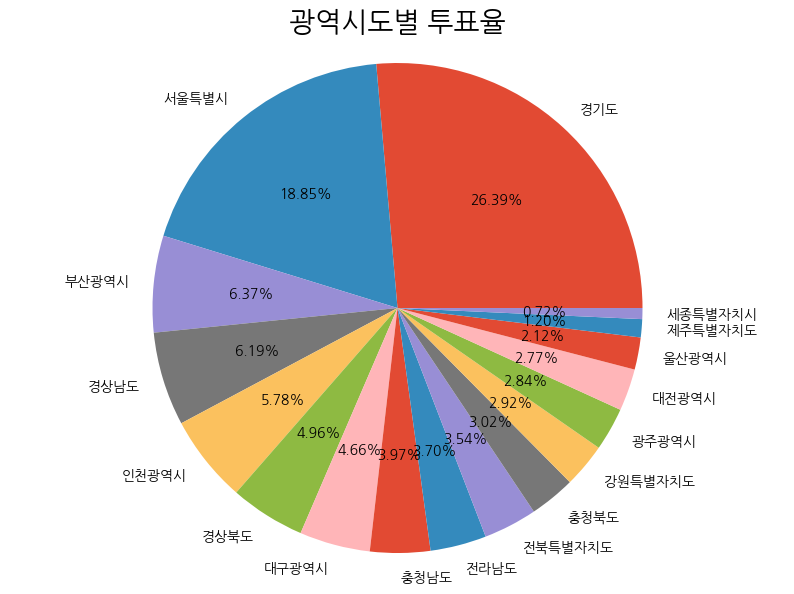

In [15]:
plt.style.use('ggplot')

elec_sum_order.투표수.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  # colors=['chocolate','bisque','cadetblue'],
  labels = elec_sum_order.index,
  ylabel=''
)

plt.title("광역시도별 투표율", size=20)
plt.axis('equal')
plt.rcParams['font.size'] = 10 # 폰트 사이즈

# plt.legend(
#   labels = df_origin_name
# )

plt.show()

In [16]:
# 이재명 후보의 광역시도별 득표율


elec_lee_je_sum = \
  election.pivot_table(
    values='이재명',
    index='광역시도',
    aggfunc='sum' # 빈도수
  )
elec_lee_je_sum.head()

,이재명
광역시도,
강원특별자치도,449161
경기도,4821148
경상남도,851733
경상북도,442683
광주광역시,844682


In [17]:
# 투표수별 순차를 내림차순으로 정렬하자

elec_lee_je_sum_order = elec_lee_je_sum.sort_values(by='이재명',ascending=False)
elec_lee_je_sum_order.head()

,이재명
광역시도,
경기도,4821148
서울특별시,3105459
전라남도,1111941
인천광역시,1044295
전북특별자치도,1023272


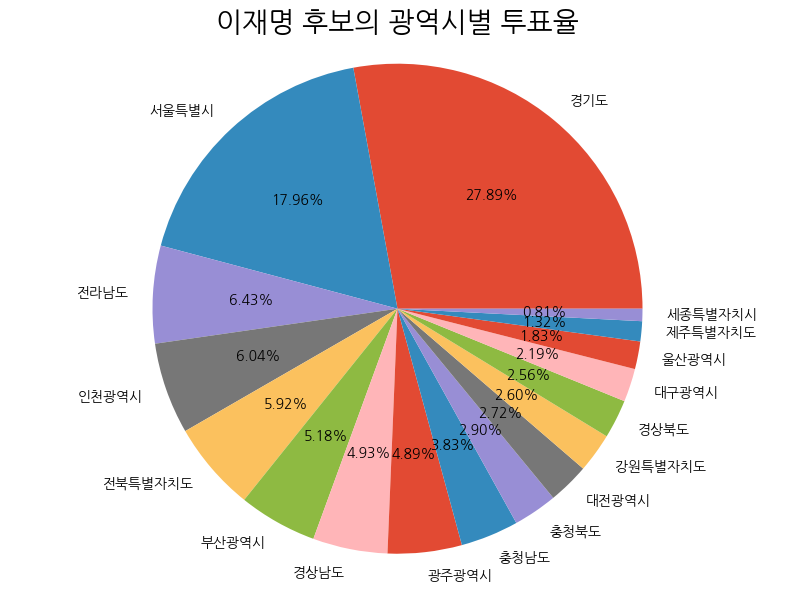

In [18]:
plt.style.use('ggplot')

elec_lee_je_sum_order.이재명.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  # colors=['chocolate','bisque','cadetblue'],
  labels = elec_lee_je_sum_order.index,
  ylabel=''
)

plt.title("이재명 후보의 광역시별 투표율", size=20)
plt.axis('equal')
plt.rcParams['font.size'] = 10 # 폰트 사이즈

# plt.legend(
#   labels = df_origin_name
# )

plt.show()

In [19]:
# 김문수 후보의 광역시도별 득표율


elec_kim_sum = \
  election.pivot_table(
    values='김문수',
    index='광역시도',
    aggfunc='sum' # 빈도수
  )
elec_kim_sum.head()

,김문수
광역시도,
강원특별자치도,483360
경기도,3504620
경상남도,1123843
경상북도,1159594
광주광역시,79937


In [20]:
# 투표수별 순차를 내림차순으로 정렬하자

elec_kim_sum_order = elec_kim_sum.sort_values(by='김문수',ascending=False)
elec_kim_sum_order.head()

,김문수
광역시도,
경기도,3504620
서울특별시,2738405
경상북도,1159594
부산광역시,1146238
경상남도,1123843


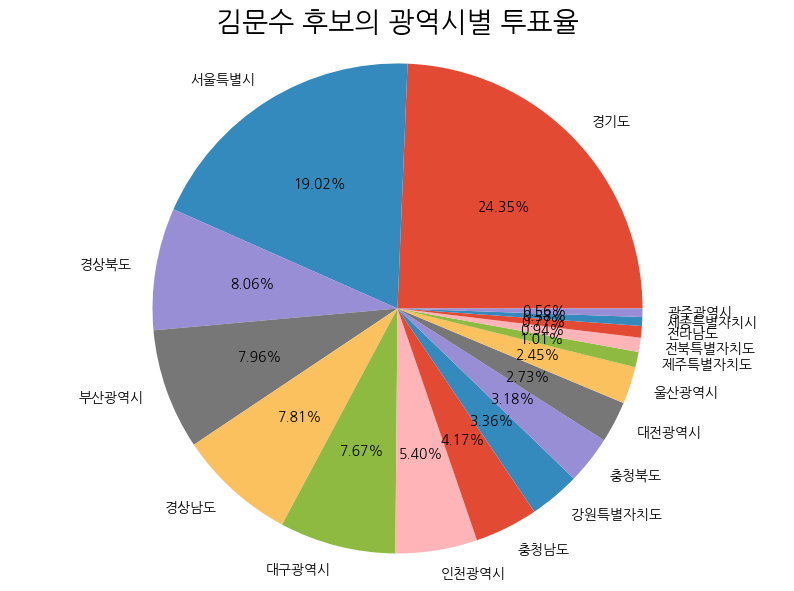

In [21]:
plt.style.use('ggplot')

elec_kim_sum_order.김문수.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  # colors=['chocolate','bisque','cadetblue'],
  labels = elec_kim_sum_order.index,
  ylabel=''
)

plt.title("김문수 후보의 광역시별 투표율", size=20)
plt.axis('equal')
plt.rcParams['font.size'] = 10 # 폰트 사이즈

# plt.legend(
#   labels = df_origin_name
# )

plt.show()

In [22]:
# 이준석 후보의 광역시도별 득표율


elec_lee_zun_sum = \
  election.pivot_table(
    values='이준석',
    index='광역시도',
    aggfunc='sum' # 빈도수
  )
elec_lee_zun_sum.head()

,이준석
광역시도,
강원특별자치도,78704
경기도,816435
경상남도,161579
경상북도,116094
광주광역시,62104


In [23]:
# 투표수별 순차를 내림차순으로 정렬하자

elec_lee_zun_sum_order = elec_lee_zun_sum.sort_values(by='이준석',ascending=False)
elec_lee_zun_sum_order.head()

,이준석
광역시도,
경기도,816435
서울특별시,655346
인천광역시,176739
부산광역시,168473
경상남도,161579


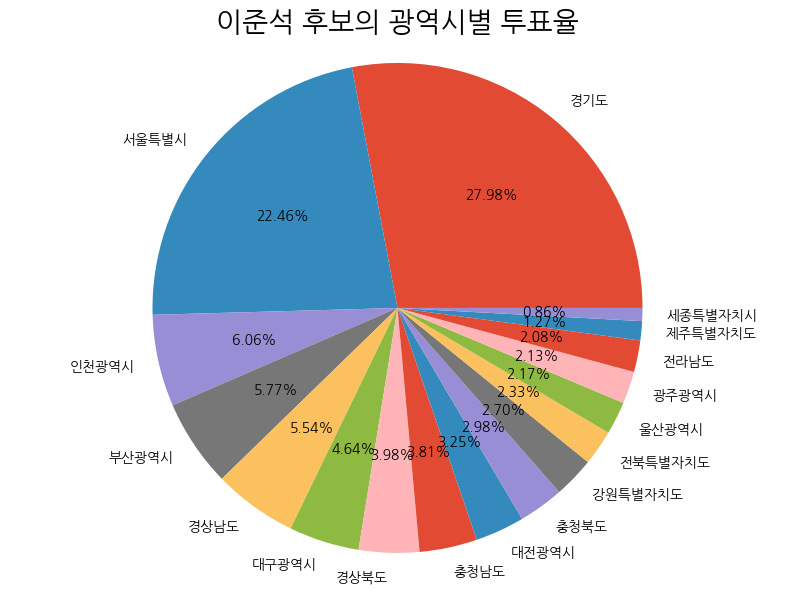

In [41]:
plt.style.use('ggplot')

elec_lee_zun_sum_order.이준석.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  # colors=['chocolate','bisque','cadetblue'],
  # labels = elec_lee_zun_sum_order.index,
  ylabel=''
)

plt.title("이준석 후보의 광역시별 투표율", size=20)
plt.axis('equal')
plt.rcParams['font.size'] = 10 # 폰트 사이즈

# plt.legend(
#   labels = df_origin_name
# )

plt.show()

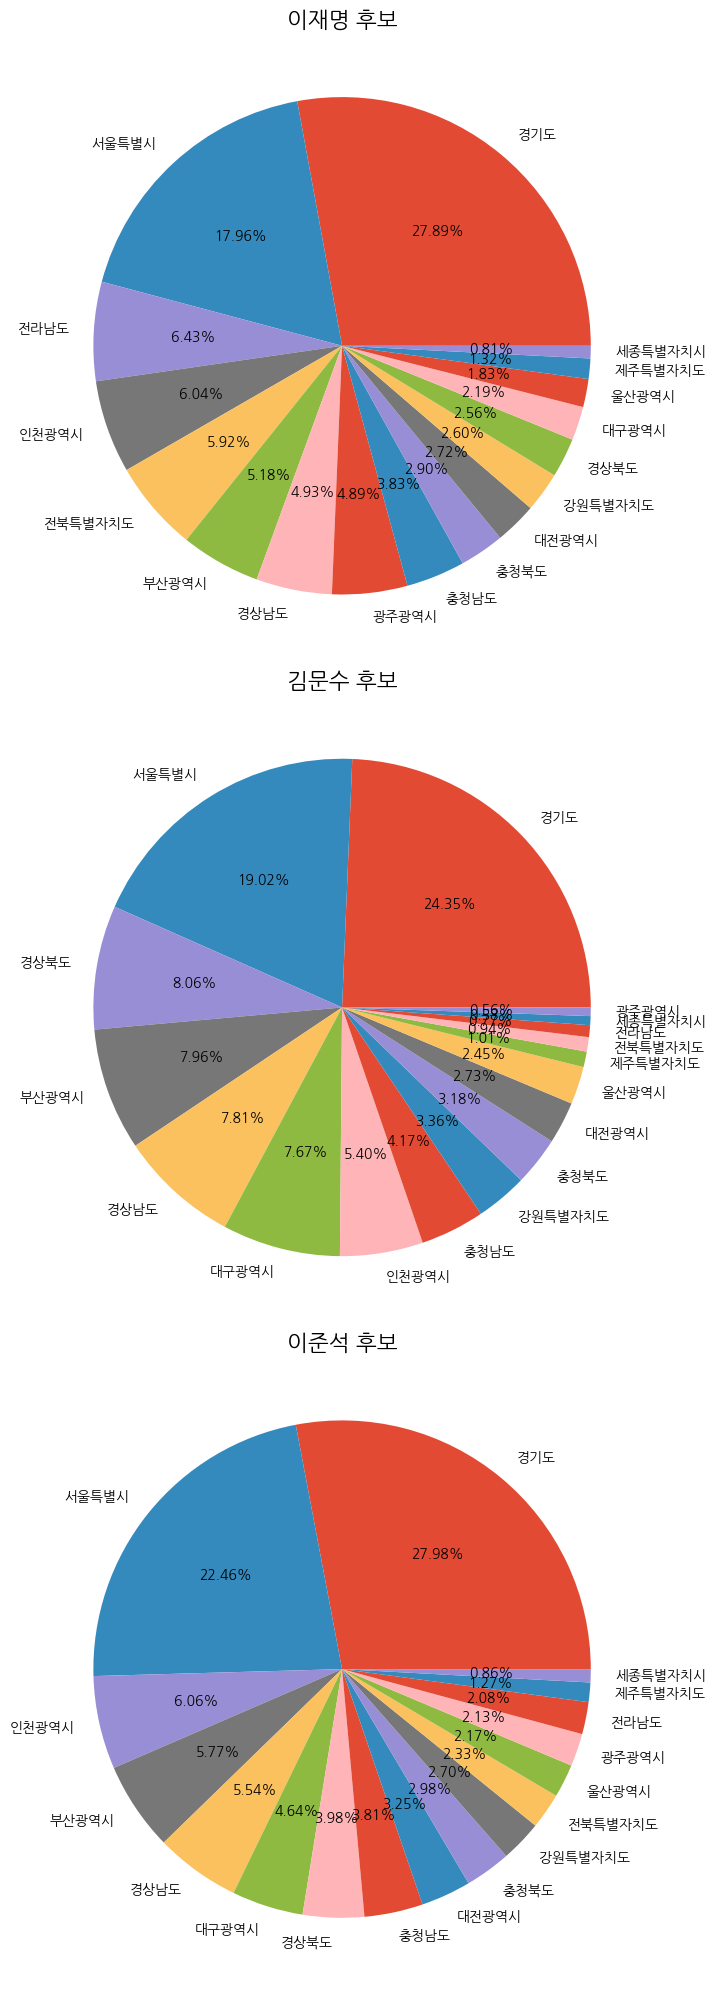

In [40]:

plt.style.use('ggplot')

fig = plt.figure(figsize=(30, 20))
ax1 = fig.add_subplot(3, 1, 1)
ax2 = fig.add_subplot(3, 1, 2)
ax3 = fig.add_subplot(3, 1, 3)  # 1행 3열의 subplot 구성

# 이재명 후보
elec_lee_je_sum_order['이재명'].plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=0,
    ylabel='',
    ax=ax1
)
ax1.set_title("이재명 후보", fontsize=16)

# 김문수 후보
elec_kim_sum_order['김문수'].plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=0,
    ylabel='',
    ax=ax2
)
ax2.set_title("김문수 후보", fontsize=16)

# 이준석 후보
elec_lee_zun_sum_order.이준석.plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=0,
    ylabel='',
    ax=ax3


    
)
ax3.set_title("이준석 후보", fontsize=16)

plt.tight_layout()
plt.show()

In [26]:
# 이재명 후보의 서울 득표 



elec_lee_seoul_sum = election[election['광역시도'] == '서울특별시'].pivot_table(
    values='이재명',
    index='시군구',
    aggfunc='sum'
  )

elec_lee_seoul_sum.head()


,이재명
시군구,
강남구,119722
강동구,160645
강북구,105780
강서구,196256
관악구,171149


In [27]:
# 투표수별 순차를 내림차순으로 정렬하자

elec_lee_seoul_sum_order = elec_lee_seoul_sum.sort_values(by='이재명',ascending=False)
elec_lee_seoul_sum_order.head()

# 상위 5개 추출
elec_lee_seoul_top5 = elec_lee_seoul_sum_order.head(5)

# 나머지 합산
etc = pd.DataFrame(
  {
    '이재명': [elec_lee_seoul_sum_order.iloc[5:]['이재명'].sum()]
  },
    index=['기타']
)

# top5와 기타를 concat으로 합치기
elec_lee_seoul_top5_with_etc = pd.concat([elec_lee_seoul_top5, etc])

# 확인
print(elec_lee_seoul_top5_with_etc)

         이재명
강서구   196256
송파구   191678
노원구   176604
은평구   171417
관악구   171149
기타   2198355


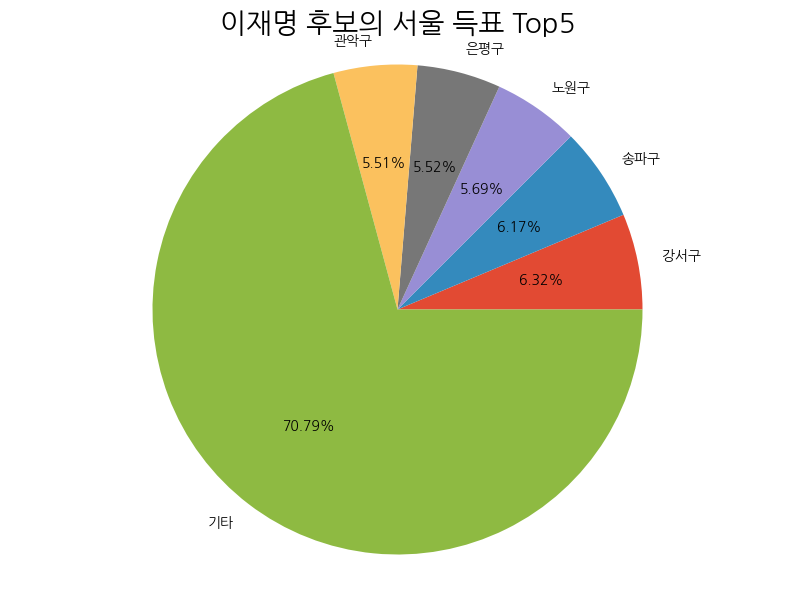

In [43]:
plt.style.use('ggplot')

plt.rcParams['font.size'] = 10 # 폰트 사이즈

elec_lee_seoul_top5_with_etc.이재명.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  # colors=['chocolate','bisque','cadetblue'],
  labels = elec_lee_seoul_top5_with_etc.index,
  ylabel=''
)

plt.title("이재명 후보의 서울 득표 Top5", size=20)
plt.axis('equal')


# plt.legend(
#   labels = df_origin_name
# )

plt.show()



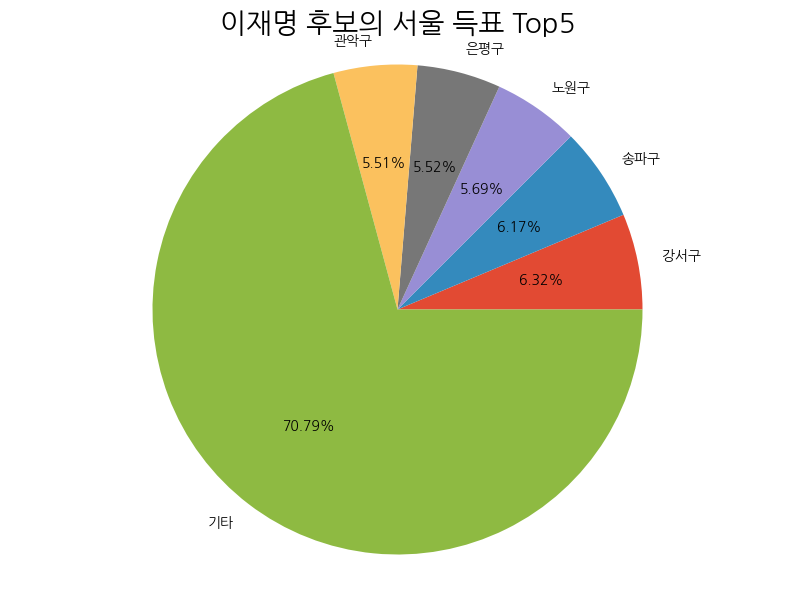

In [44]:

top5 = elec_lee_seoul_sum_order.head(5)

# 나머지를 합쳐서 '기타'로 만들기
etc_sum = elec_lee_seoul_sum_order.iloc[5:]['이재명'].sum()

# '기타' 추가
top5_with_etc = top5.copy()
top5_with_etc.loc['기타'] = etc_sum

# 파이 차트 그리기
plt.style.use('ggplot')
top5_with_etc['이재명'].plot(
    kind='pie',
    figsize=(10, 7),
    autopct='%.2f%%',
    startangle=0,
    # labels=top5_with_etc.index,
    ylabel=''
)

plt.title("이재명 후보의 서울 득표 Top5", size=20)
plt.axis('equal')
plt.rcParams['font.size'] = 10
plt.show()

### 대선주자 출생지별 득표율 분석
: 이재명 후보의 출생지는 경상북도 안동시

In [30]:
elec_lee_birth_sum = election[
    (election['광역시도'] == '경상북도') & (election['시군구'] == '안동시')
].pivot_table(
    values=['이재명','김문수','이준석'],
    index='시군구',
    aggfunc='sum'
)
elec_lee_birth_sum = elec_lee_birth_sum[['이재명', '김문수', '이준석']]
elec_lee_birth_sum.head()



,이재명,김문수,이준석
시군구,,,
안동시,33560,65739,7050


In [46]:
# etc 컬럼 추가
election['기타'] = election['투표수'] - election['electionSum']

# election

# # etc만 추출한 데이터프레임 생성
# etc = election[['광역시도', '시군구', '기타']]

# 확인
elec_lee_birth_etc = election[
    (election['광역시도'] == '경상북도') & (election['시군구'] == '안동시')
].pivot_table(
    values=['기타'],
    index='시군구',
    aggfunc='sum'
)
elec_lee_birth_etc




,기타
시군구,
안동시,1867


In [32]:
elec_lee_birth_sum_withetc = pd.concat([elec_lee_birth_sum, elec_lee_birth_etc], axis='columns')

elec_lee_birth_sum_withetc  = elec_lee_birth_sum_withetc.T

elec_lee_birth_sum_withetc

시군구,안동시
이재명,33560
김문수,65739
이준석,7050
기타,1867


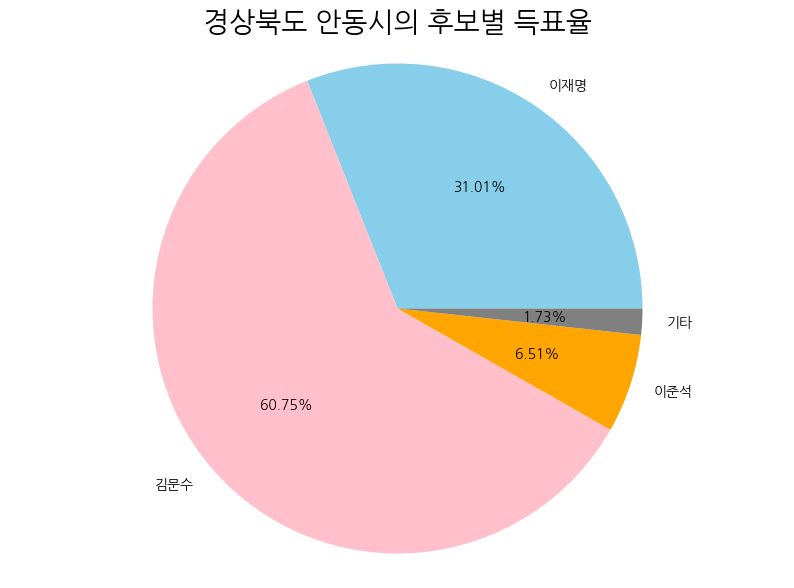

In [50]:
plt.style.use('ggplot')

plt.rcParams['font.size'] = 10 # 폰트 사이즈

elec_lee_birth_sum_withetc.안동시.plot(
  kind='pie',
  figsize=(10,7),
  autopct='%.2f%%',
  startangle=0,
  colors=['skyblue','pink','orange','grey'],
  # labels = elec_lee_birth_sum_withetc.index,
  ylabel=''
)

plt.title("경상북도 안동시의 후보별 득표율", size=20)
plt.axis('equal')


# plt.legend(
#   labels = df_origin_name
# )

plt.show()

---
### 투표수가 가장 많은 4지역(광역시도)의 각 후보별 득표수를 막대그래프로 표현하기

In [34]:
elec_sum = \
  election.pivot_table(
    ['투표수','이재명','김문수','이준석'],
    index='광역시도',
    aggfunc='sum' # 빈도수
  )

elec_sum.head()

# 투표수별 순차를 내림차순으로 정렬하자

elec_sum = elec_sum.sort_values(by='투표수',ascending=False)


elec_top4 = elec_sum.head(4)

elec_top4 = elec_top4.drop('투표수', axis=1)

elec_top4 = elec_top4[['이재명', '김문수', '이준석']]

elec_top4
# # 상위 5개 추출
# elec_lee_seoul_top5 = elec_lee_seoul_sum_order.head(5)


,이재명,김문수,이준석
광역시도,,,
경기도,4821148,3504620,816435
서울특별시,3105459,2738405,655346
부산광역시,895213,1146238,168473
경상남도,851733,1123843,161579


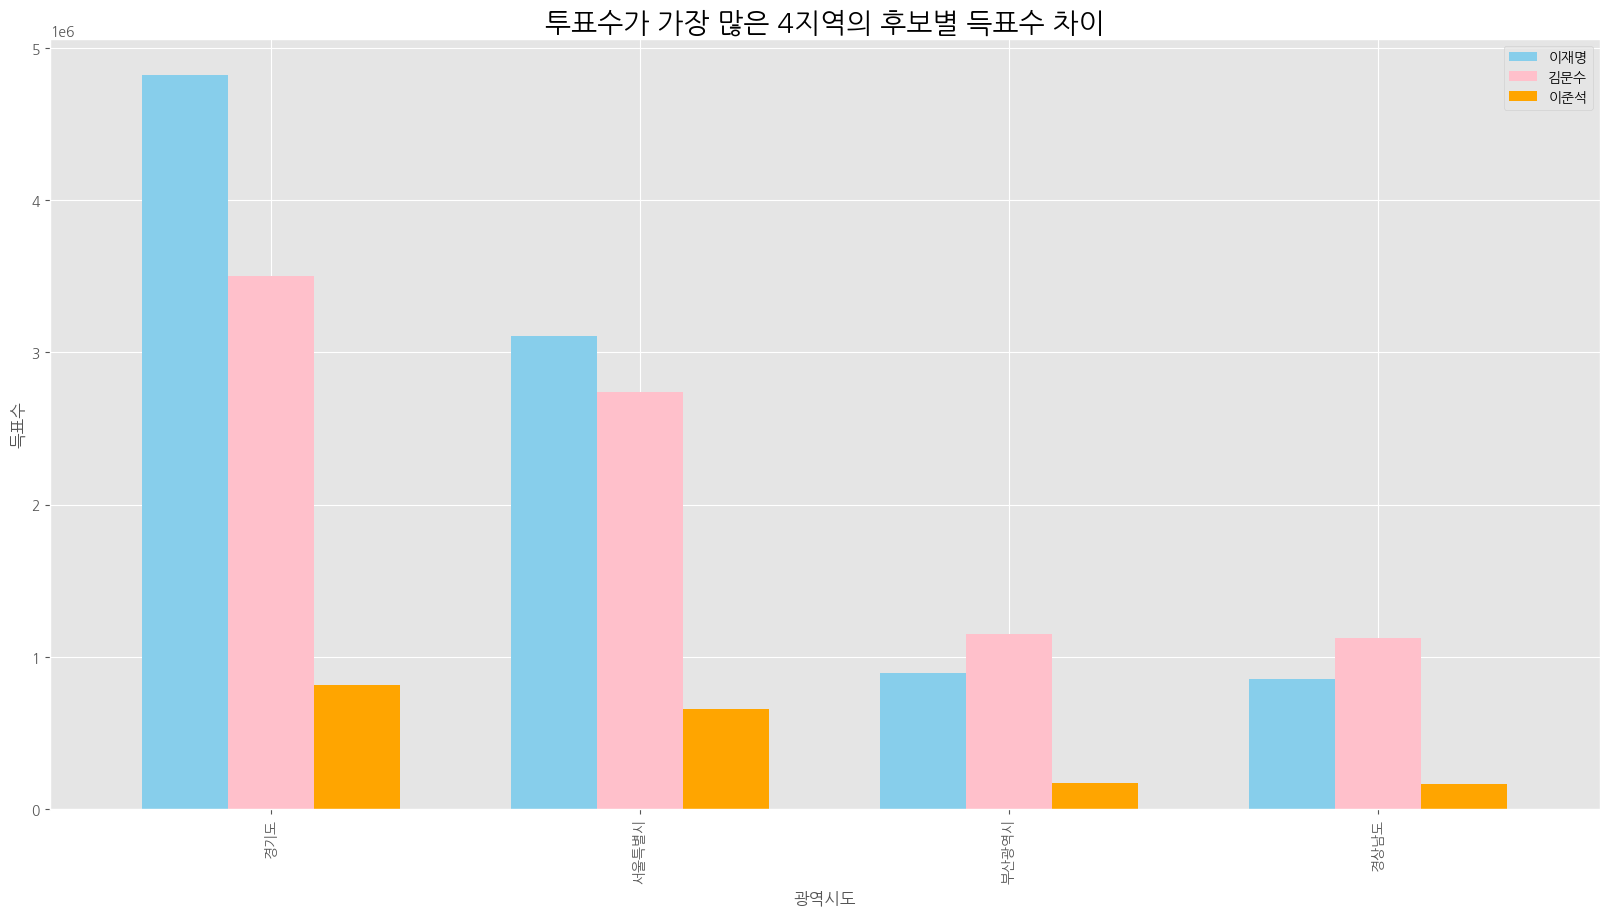

In [35]:
plt.style.use('ggplot')

elec_top4.plot(
  kind='bar',
  figsize=(20,10),
  color=['skyblue','pink','orange'],
  width=0.7,
  ylabel='득표수'
)

plt.title("투표수가 가장 많은 4지역의 후보별 득표수 차이", size=20)

plt.show()

In [36]:
### 투표수가 높은 시군의 후보별 득표수
elec_sum = \
  election.pivot_table(
    ['투표수','이재명','김문수','이준석'],
    index=['광역시도','시군구'],
    aggfunc='sum' # 빈도수
  )

elec_sum.head()

# 투표수별 순차를 내림차순으로 정렬하자

elec_sum = elec_sum.sort_values(by='투표수',ascending=False)


elec_top5 = elec_sum.head()

elec_top5 = elec_top5[['이재명', '김문수', '이준석','투표수']]

elec_top5 = elec_top5.drop('투표수', axis=1)


df = elec_top5.reset_index()

# concat으로 광역시도와 시군구 합치기
df['지역'] = pd.concat([df['광역시도'], df['시군구']], axis=1).agg(' '.join, axis=1)

df.set_index('지역', inplace=True)
df = df.drop(['광역시도','시군구'], axis=1)
df


,이재명,김문수,이준석
지역,,,
경기도 남양주시,261539,179144,36668
서울특별시 송파구,191678,212094,46194
인천광역시 서구,223841,147562,38226
서울특별시 강서구,196256,149837,38416
경기도 평택시,193007,147716,34980


In [37]:
import matplotlib.pyplot as plt
import pandas as pd

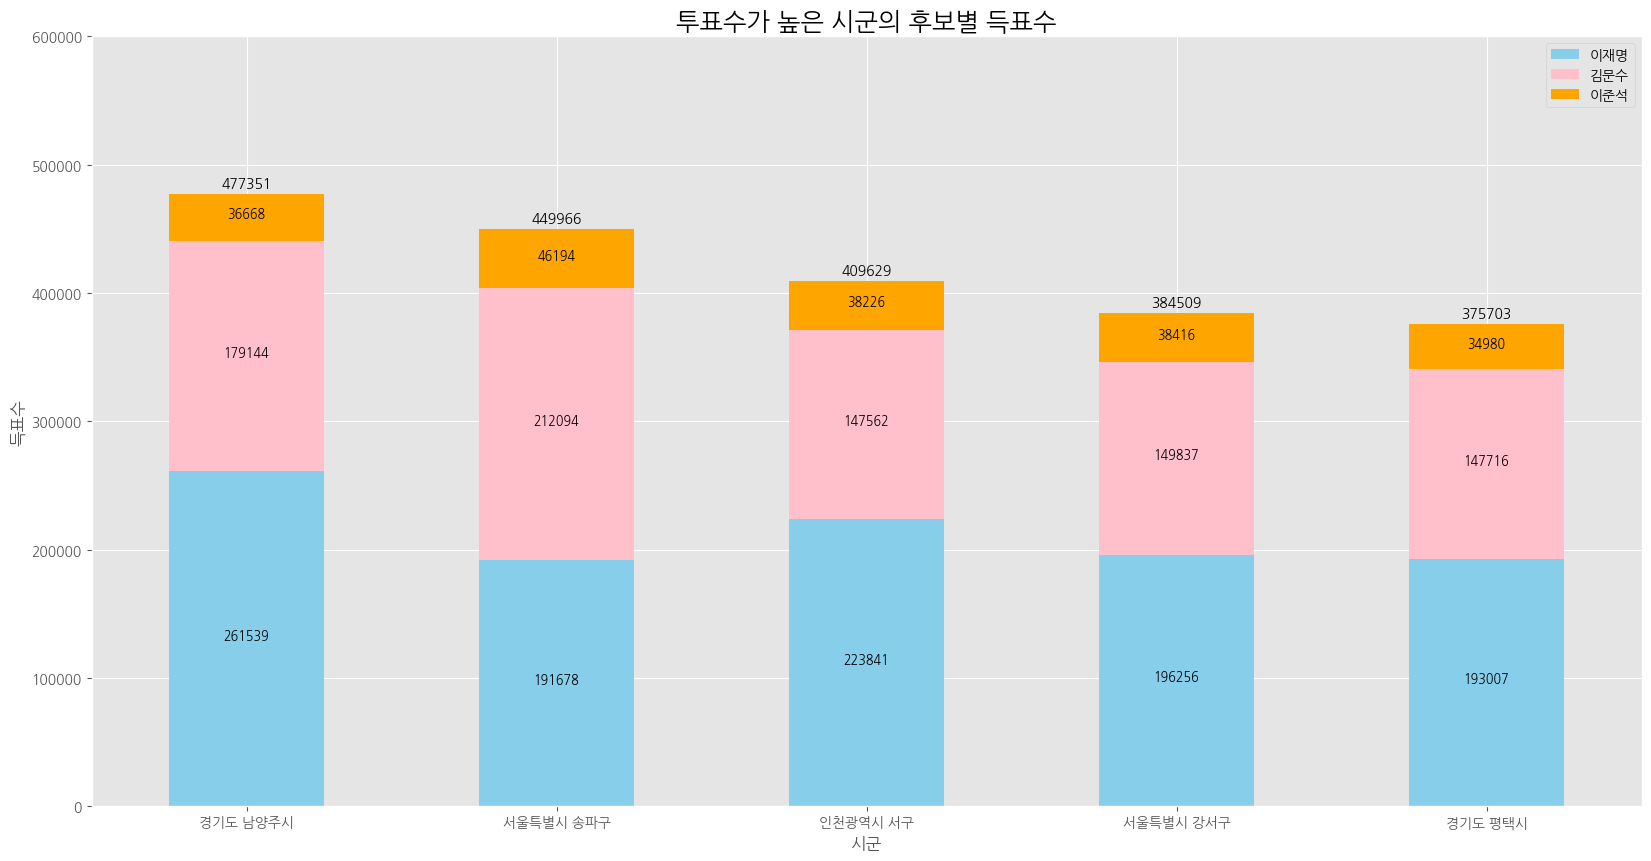

In [52]:
# 누적 막대그래프


plt.style.use('ggplot')

ax = df.plot(
    kind='bar',
    stacked=True,
    figsize=(20, 10),
    color=['skyblue', 'pink', 'orange']
)

plt.ylim(0, 600000)
plt.xticks(rotation=0)
plt.title("투표수가 높은 시군의 후보별 득표수", fontsize=18)
plt.ylabel("득표수")
plt.xlabel("시군")
plt.legend()


for plot_idx, (region_idx, row) in enumerate(df[['이재명', '김문수', '이준석']].iterrows()):
    cum_height = 0

    for col in ['이재명', '김문수', '이준석']:
        val = row[col]
        plt.annotate(
            val,
            xy=(plot_idx, cum_height + val / 2),
            ha='center',
            fontsize=9,
            color='black'
        )
        cum_height += val

    total = row.sum()
    plt.annotate(
        total,
        xy=(plot_idx, total),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        color='black'
    )


plt.show()